In [3]:

import pandas as pd
df = pd.read_csv('../data/raw/telco_churn.csv')
X = df.drop('Churn', axis=1)

In [4]:
# ============================================
# SECTION 3: CLASSICAL ML MODELS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── ML imports ────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     roc_auc_score, confusion_matrix,
                                     classification_report, roc_curve)
from imblearn.over_sampling  import SMOTE
from xgboost                 import XGBClassifier

# ── Load saved numpy arrays directly ─────────
X_train_bal  = np.load('../data/processed/X_train.npy',allow_pickle=True)
X_test_sc    = np.load('../data/processed/X_test.npy',allow_pickle=True)
y_train_bal  = np.load('../data/processed/y_train.npy',allow_pickle=True)
y_test       = np.load('../data/processed/y_test.npy',allow_pickle=True)

# ── Load feature names ────────────────────────
feature_names = pd.read_csv('../data/processed/feature_names.csv').iloc[:, 0].tolist()
n_features    = X_train_bal.shape[1]

print("✅ Data loaded directly from saved files!")
print(f"X_train : {X_train_bal.shape}")
print(f"X_test  : {X_test_sc.shape}")
print(f"y_train : {y_train_bal.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Features: {n_features}")
print(f"data types: {X_train_bal.dtype}, {y_train_bal.dtype}")
print("✅ Libraries loaded!")


✅ Data loaded directly from saved files!
X_train : (8278, 28)
X_test  : (1409, 28)
y_train : (8278,)
y_test  : (1409,)
Features: 28
data types: object, int64
✅ Libraries loaded!


In [5]:
# ============================================
# MASTER EVALUATION FUNCTION
# Write once — reuse for every model!
# This is the professional way
# ============================================

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """
    Full evaluation of any classifier.
    Returns metrics dict + prints report.
    """
    # ── Predictions ───────────────────────────
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # ── Metrics ───────────────────────────────
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)\

    # ── Cross Validation ──────────────────────
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores   = cross_val_score(model, X_train, y_train,
                                   cv=cv, scoring='roc_auc')

    # ── Print Report ──────────────────────────
    print(f"\n{'='*55}")
    print(f"📊 MODEL: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy    : {accuracy:.4f}  ({accuracy*100:.1f}%)")
    print(f"  Precision   : {precision:.4f}")
    print(f"  Recall      : {recall:.4f}")
    print(f"  F1 Score    : {f1:.4f}")
    print(f"  ROC-AUC     : {roc_auc:.4f}")
    print(f"  CV ROC-AUC  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Churn', 'Churn']))

    return {
        'Model'      : name,
        'Accuracy'   : round(accuracy, 4),
        'Precision'  : round(precision, 4),
        'Recall'     : round(recall, 4),
        'F1'         : round(f1, 4),
        'ROC_AUC'    : round(roc_auc, 4),
        'CV_ROC_AUC' : round(cv_scores.mean(), 4),
        'CV_Std'     : round(cv_scores.std(), 4),
        'Model_Obj'  : model,
        'y_pred_prob': y_pred_prob
    }

print("✅ Evaluation function ready!")

✅ Evaluation function ready!


In [6]:
# ============================================
# MODEL 1 — LOGISTIC REGRESSION
# Always your baseline — simple and explainable
# If this gets 80%, your other models must beat it
# ============================================

lr_model = LogisticRegression(
    max_iter     = 1000,
    random_state = 42,
    C            = 1.0      # regularization strength
)

lr_model.fit(X_train_bal, y_train_bal)

lr_results = evaluate_model(
    'Logistic Regression',
    lr_model,
    X_train_bal, y_train_bal,
    X_test_sc,   y_test
)


📊 MODEL: Logistic Regression
  Accuracy    : 0.7473  (74.7%)
  Precision   : 0.5170
  Recall      : 0.7326
  F1 Score    : 0.6062
  ROC-AUC     : 0.8279
  CV ROC-AUC  : 0.8821 ± 0.0046

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1035
       Churn       0.52      0.73      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'ChargesRatio', 'NumServices', 'IsAutoPay', 'IsLongTermContract', 'IsHighValue', 'Internet_DSL', 'Internet_Fiber optic', 'Internet_No', 'Payment_Credit card (automatic)', 'Payment_Electronic check', 'Payment_Mailed check']

📊 TOP 10 FEATURES — Logistic Regression:
                 Feature  Coefficient
          MonthlyCharges     3.927881
            Internet_DSL     3.591270
          OnlineSecurity    -3.243892
             TechSupport    -3.152222
            PhoneService    -2.540924
           MultipleLines    -2.365810
Payment_Electronic check     2.357514
    Payment_Mailed check     1.947723
             NumServices     1.891474
             Internet_No     1.571371


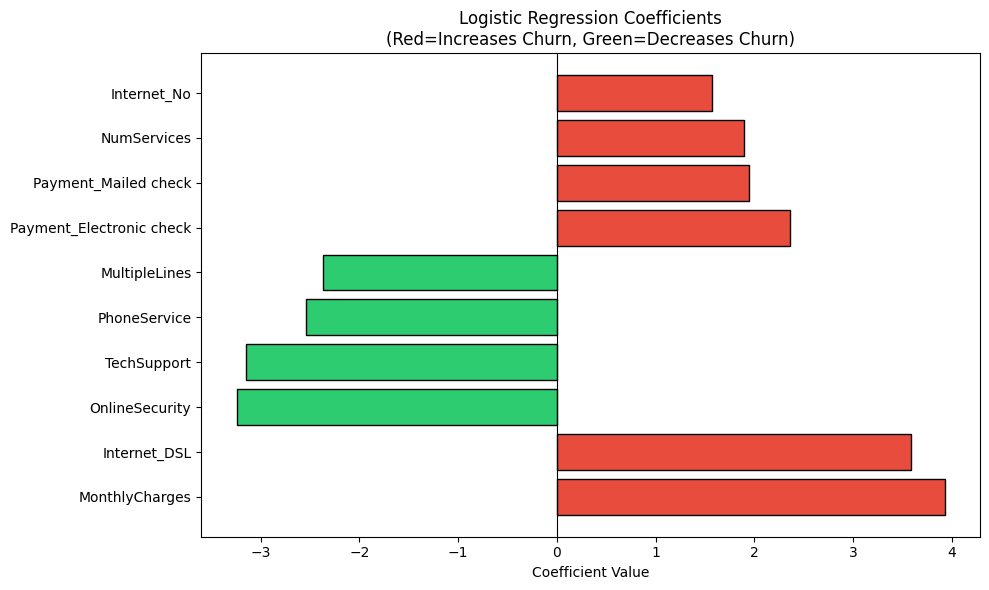

In [ ]:
# ── Logistic Regression Coefficients ──────────
# This tells you WHICH features drive churn


# feature_names is already loaded as a list of 28 names
feature_names = list(feature_names)
print(feature_names)
coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coef'   : np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coef', ascending=False)

print("\n📊 TOP 10 FEATURES — Logistic Regression:")
print(coef_df.head(10)[['Feature', 'Coefficient']].to_string(index=False))

# ── Visualize coefficients ────────────────────
plt.figure(figsize=(10, 6))
top_coef = coef_df.head(10)

colors = ['#e74c3c' if c > 0 else '#2ecc71' 
          for c in top_coef['Coefficient']]

plt.barh(top_coef['Feature'], top_coef['Coefficient'],
         color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Red=Increases Churn, Green=Decreases Churn)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../reports/lr_coefficients.png', dpi=150)
plt.show()

In [15]:
# ============================================
# MODEL 2 — RANDOM FOREST
# Ensemble of decision trees
# Gives feature importance automatically!
# ============================================

rf_model = RandomForestClassifier(
    n_estimators = 200,     # number of trees
    max_depth    = 10,      # prevent overfitting
    min_samples_split = 10,
    random_state = 42,
    n_jobs       = -1       # use all CPU cores
)

rf_model.fit(X_train_bal, y_train_bal)

rf_results = evaluate_model(
    'Random Forest',
    rf_model,
    X_train_bal, y_train_bal,
    X_test_sc,   y_test
)



📊 MODEL: Random Forest
  Accuracy    : 0.7573  (75.7%)
  Precision   : 0.5315
  Recall      : 0.7219
  F1 Score    : 0.6122
  ROC-AUC     : 0.8344
  CV ROC-AUC  : 0.8983 ± 0.0036

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.77      0.82      1035
       Churn       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409




📊 TOP 10 FEATURES — Random Forest:
                 Feature  Importance
                Contract    0.138093
      IsLongTermContract    0.136085
                  tenure    0.100039
            TotalCharges    0.077399
          MonthlyCharges    0.074259
Payment_Electronic check    0.064913
    Internet_Fiber optic    0.062072
            ChargesRatio    0.046151
             TechSupport    0.034714
          OnlineSecurity    0.034244


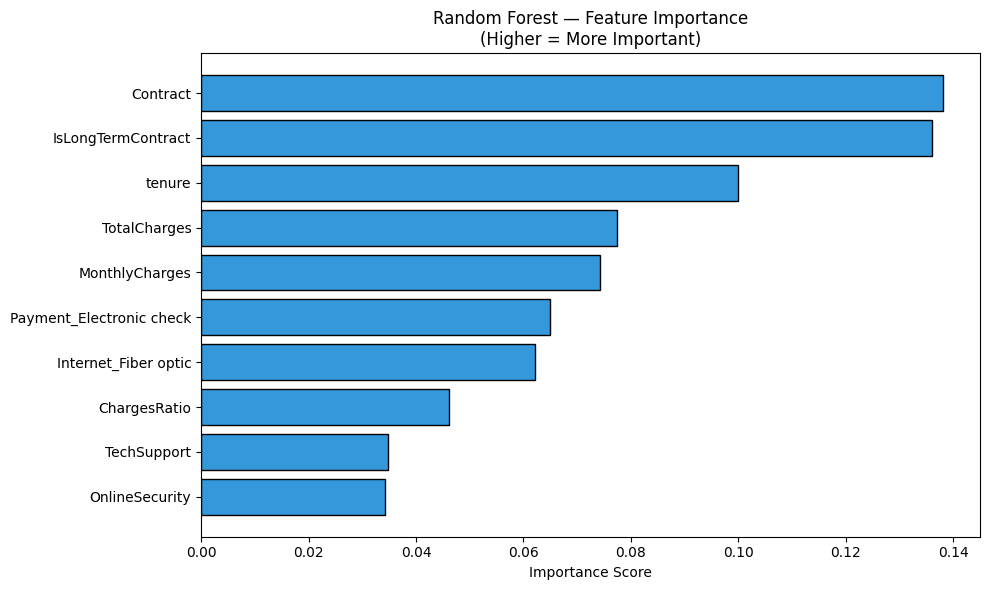

In [16]:
# ── Random Forest Feature Importance ──────────
# This is MORE reliable than LR coefficients
feat_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 TOP 10 FEATURES — Random Forest:")
print(feat_imp.head(10).to_string(index=False))

# ── Visualize ─────────────────────────────────
plt.figure(figsize=(10, 6))
plt.barh(feat_imp.head(10)['Feature'],
         feat_imp.head(10)['Importance'],
         color='#3498db', edgecolor='black')
plt.title('Random Forest — Feature Importance\n(Higher = More Important)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/rf_feature_importance.png', dpi=150)
plt.show()

In [17]:
# ============================================
# MODEL 3 — XGBOOST
# Gradient boosting — industry gold standard
# Used in 90% of winning Kaggle solutions
# ============================================

# Calculate imbalance ratio for scale_pos_weight
neg_count  = (y_train_bal == 0).sum()
pos_count  = (y_train_bal == 1).sum()
scale_weight = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_weight,
    random_state      = 42,
    eval_metric       = 'logloss',
    verbosity         = 0
)

xgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set              = [(X_test_sc, y_test)],
    verbose               = False
)

xgb_results = evaluate_model(
    'XGBoost',
    xgb_model,
    X_train_bal, y_train_bal,
    X_test_sc,   y_test
)


📊 MODEL: XGBoost
  Accuracy    : 0.7715  (77.1%)
  Precision   : 0.5578
  Recall      : 0.6711
  F1 Score    : 0.6092
  ROC-AUC     : 0.8251
  CV ROC-AUC  : 0.9106 ± 0.0040

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



In [18]:
# ============================================
# MODEL COMPARISON — Side by side
# ============================================

all_results = [lr_results, rf_results, xgb_results]

comparison_df = pd.DataFrame([{
    'Model'      : r['Model'],
    'Accuracy'   : r['Accuracy'],
    'Precision'  : r['Precision'],
    'Recall'     : r['Recall'],
    'F1'         : r['F1'],
    'ROC_AUC'    : r['ROC_AUC'],
    'CV_ROC_AUC' : r['CV_ROC_AUC']
} for r in all_results])

print("\n")
print("=" * 70)
print("🏆 MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.to_string(index=False))

best_model = comparison_df.loc[comparison_df['ROC_AUC'].idxmax(), 'Model']
print(f"\n🥇 Best Model by ROC-AUC: {best_model}")



🏆 MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall     F1  ROC_AUC  CV_ROC_AUC
Logistic Regression    0.7473     0.5170  0.7326 0.6062   0.8279      0.8821
      Random Forest    0.7573     0.5315  0.7219 0.6122   0.8344      0.8983
            XGBoost    0.7715     0.5578  0.6711 0.6092   0.8251      0.9106

🥇 Best Model by ROC-AUC: Random Forest


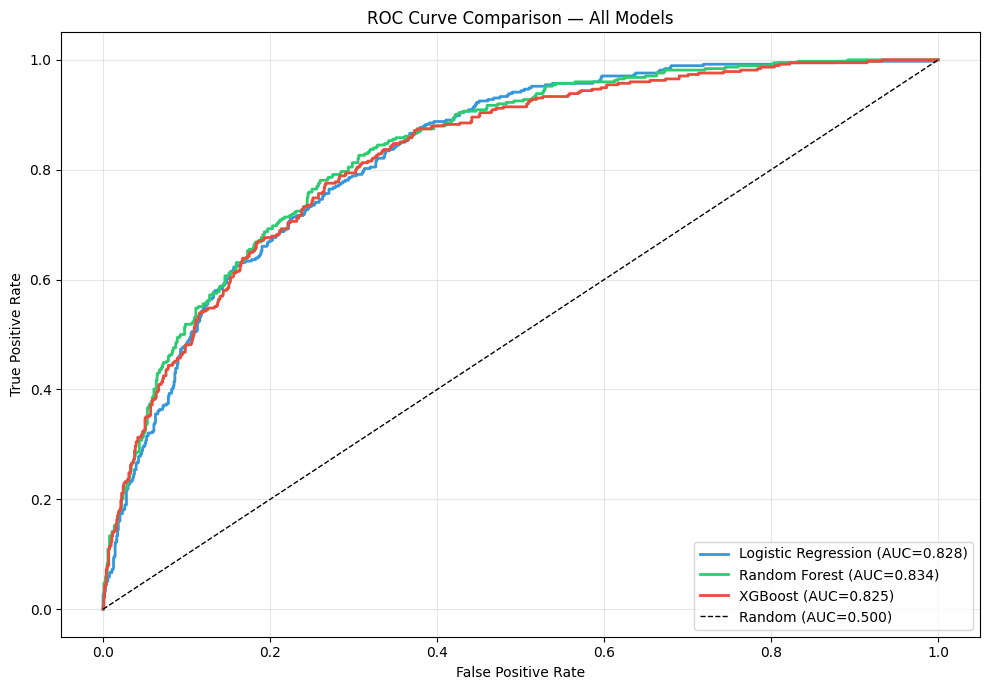

In [19]:
# ── ROC Curve Comparison ──────────────────────
plt.figure(figsize=(10, 7))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for result, color in zip(all_results, colors):
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_prob'])
    plt.plot(fpr, tpr,
             label  = f"{result['Model']} (AUC={result['ROC_AUC']:.3f})",
             color  = color,
             linewidth = 2)

# Random baseline
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_comparison.png', dpi=150)
plt.show()

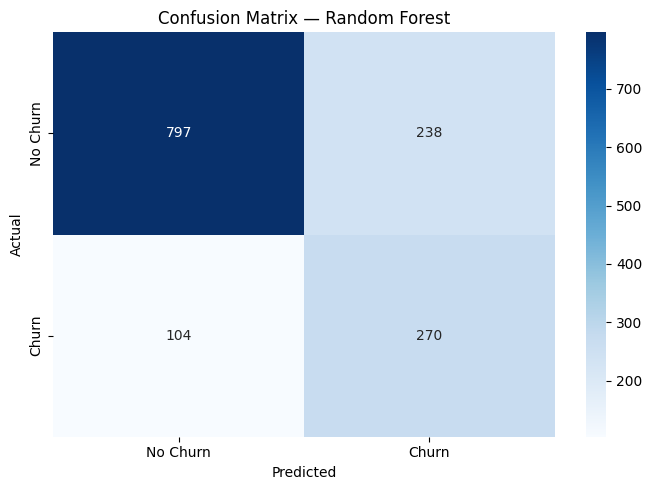


╔══════════════════════════════════════════════════╗
║         BUSINESS TRANSLATION                     ║
╠══════════════════════════════════════════════════╣
║ True Negatives   797 → Correctly said NO churn ║
║ True Positives   270 → Correctly caught churn  ║
║ False Positives  238 → Wrongly flagged loyal   ║
║ False Negatives  104 → Missed actual churners  ║
╠══════════════════════════════════════════════════╣
║ ⚠️  False Negatives cost most — missed churners! ║
╚══════════════════════════════════════════════════╝



In [20]:
# ── Confusion Matrix for Best Model ───────────
best_result = max(all_results, key=lambda x: x['ROC_AUC'])
y_pred_best = best_result['Model_Obj'].predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot      = True,
            fmt        = 'd',
            cmap       = 'Blues',
            xticklabels= ['No Churn', 'Churn'],
            yticklabels= ['No Churn', 'Churn'])

plt.title(f'Confusion Matrix — {best_result["Model"]}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

# ── Business Translation ───────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"""
╔══════════════════════════════════════════════════╗
║         BUSINESS TRANSLATION                     ║
╠══════════════════════════════════════════════════╣
║ True Negatives  {tn:4d} → Correctly said NO churn ║
║ True Positives  {tp:4d} → Correctly caught churn  ║
║ False Positives {fp:4d} → Wrongly flagged loyal   ║
║ False Negatives {fn:4d} → Missed actual churners  ║
╠══════════════════════════════════════════════════╣
║ ⚠️  False Negatives cost most — missed churners! ║
╚══════════════════════════════════════════════════╝
""")

In [ ]:
""""Accuracy  → MISLEADING for imbalanced data
            74% accuracy by saying "No Churn" always!

Precision → Of all customers we PREDICTED churn
            how many actually churned?
            High precision = fewer false alarms

Recall    → Of all customers who ACTUALLY churned
            how many did we catch?
            High recall = fewer missed churners
            ⭐ MORE IMPORTANT for business!

F1        → Balance between Precision and Recall
            Use when both matter equally

ROC-AUC   → Overall model quality regardless of threshold
            > 0.80 = good   > 0.90 = excellent
            ⭐ BEST single metric for this problem """

In [ ]:
"""I chose ROC-AUC as my primary metric because
 accuracy is misleading on imbalanced datasets.
 A model predicting No Churn always gets 74%
 accuracy but catches zero churners — useless!

 I also prioritized Recall over Precision because
 missing a churner costs the business more than
 a false alarm — it's cheaper to offer a discount
 to a loyal customer than to lose a real churner."""